# 02 — From archives to a timing solution

**What this notebook does.** It turns P3's folded archives into a timing solution in five stages:
1. build a pulse template with PSRCHIVE;
2. measure times of arrival (ToAs) with `pat`;
3. connect the ToAs visit by visit with PINT;
4. install the improved ephemeris back into the archives;
5. compare the result with the simulation's true parameters.

P3 is a 6.1 ms millisecond pulsar in a 4.4-day orbit with a white dwarf.

**What it needs.** The sample under `data/` (`DATASET` below) and the `convening2026` conda
environment (PSRCHIVE, PINT, ipywidgets).

**How to run it.** *Kernel → Restart & Run All.* It takes about 3–5 minutes.

**Outputs.** Templates, ToAs and the fitted ephemeris are written to `DATASET/templates/` if that folder
is writable, otherwise to `./output_02/` next to this notebook.

**Everything here is simulated.** Optional `answer_key/` under `data/` holds simulation truth for self-checks;
the last section skips if it is absent.


> **JupyterHub copy:** reads the release straight from the S3 mount `~/s3/schmidt-observatory-system/dsa/v1-convening/` (read-only; 6 visit-0 CHR archives and 10 DPR-DSA-07 cubes, no `MANIFEST.csv`, `fold.par`, `volume.json` or DSA-03/11/12 files). The inventory is built from the files, the folding ephemeris is read out of an archive, the phase-connection steps are limited to the visits present (visit 0 only), and outputs go to `~/convening2026_work/`.

## Set-up

Optionally edit `PSR`. Archives are loaded from `data/`; the cell chooses the output folder.
`NSUB` is the number of ToAs per 1260 s pointing used by the simulation:
- 1 for most types;
- 5 for P4 and 3 for P5, whose orbits are so short that the pointing must be split.


In [1]:
from pathlib import Path
# All sample products live under data/ (download there first; see data/README.md)
from convening2026 import chr_helpers as H
import os, warnings, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

PSR = "P3"

NSUB = {"P4": 5, "P5": 3}.get(PSR, 1)
import os
# JupyterHub: the DSA release is on the S3 bucket, NFS-mounted read-only under ~/s3. DSA_DATA overrides it (tests).
DS = Path(os.environ.get("DSA_DATA", "~/s3/schmidt-observatory-system/dsa/v1-convening")).expanduser()
WORK = Path("~/convening2026_work").expanduser(); WORK.mkdir(exist_ok=True)   # the mount is read-only: outputs go here
from astropy.io import fits
# MANIFEST.csv is not on the bucket: build the inventory from the archives.
# theta_deg / B_k / discovery (simulation metadata) are not recoverable from the files.
# PSRCHIVE 2025.04.24 (conda-forge) crashes intermittently when loading the chrpreview-written archives;
# copies rewritten once by pam (lossless up to 16-bit requantisation) load reliably.
# `path` points at the rewritten copy (for PSRCHIVE), `orig` at the original (keeps the DSA header keywords).
RW = WORK / "rewritten"; RW.mkdir(exist_ok=True)
rows = []
for p in sorted(DS.glob("*.psrfits")):
    if not (RW / p.name).exists():
        H.sh(f"pam -e psrfits -u {RW} {p}")
    h = fits.getheader(p, 0); v, ptg = H.visit_ptg(p.name)
    rows.append(dict(file=p.name, path=str(RW / p.name), orig=str(p), pulsar=h["SRC_NAME"], visit=v, ptg=ptg, discovery=False,
                     product_type="DPR-DSA-13", obs_id=h["observationID"],
                     start_mjd=h["STT_IMJD"] + h["STT_SMJD"] / 86400.0, nbin=fits.getheader(p, "SUBINT")["NBIN"]))
man = pd.DataFrame(rows)
arfile = man.path.iloc[0]
FOLD = WORK / "fold.par"
if not FOLD.exists():   # not on the bucket: recover the folding ephemeris stored in the archive's PSRPARAM HDU
    FOLD.write_text("\n".join(r[0] for r in fits.getdata(arfile, "PSRPARAM")) + "\n")
mine = man[man.pulsar == PSR].sort_values(["visit", "start_mjd"])
print(f"{PSR}: {len(mine)} archives in visits {sorted(mine.visit.unique())}; NSUB = {NSUB}")
OUT = WORK / "templates"
OUT.mkdir(exist_ok=True)
(OUT / "tF").mkdir(exist_ok=True)
print("outputs ->", OUT)


P3: 6 archives in visits [0]; NSUB = 1
outputs -> /Users/gudmundurstefansson/convening2026_work/templates


## 1. Make a template

A **template** (standard profile) is a high-S/N, noise-free model of the pulse shape. Every ToA is
measured by comparing a profile with it. We build one from the data themselves, in four steps:

1. **`pam`** (PSRCHIVE's archive modifier) reduces each archive to a single profile, writing copies into
   the output folder so the originals stay untouched. Options:
   - `-F` — sum over frequency;
   - `-T` — sum over time;
   - `-e FT` — the new file extension;
   - `-u OUT/FT` — the output folder.
2. **`pam -E fold.par -m`** installs the folding ephemeris on these copies (`-m` = modify in place).
   **Why:** to add archives from different days, PSRCHIVE needs one phase predictor that spans all of
   them. The archives carry short per-pointing predictors, so we let PSRCHIVE build a new one (with
   tempo2) from the same ephemeris. Tiny µs-level differences between predictors do not matter for a
   template's *shape*. The ToAs later are measured on the original archives.
3. **`psradd`** adds the profiles. Options:
   - `-T` — sum over time;
   - `-F` — *force*: add them even though their start times differ;
   - `-o` — the output file.
4. **`psrsmooth -W`** removes the remaining noise by wavelet smoothing; `-e std` names the output `*.std`.

We first do this for the six visit-0 archives. **What to look for:** a smooth two-component profile.

In [2]:
(OUT / "FT").mkdir(exist_ok=True)
print(H.sh(f"pam -F -T -e FT -u {OUT}/FT {' '.join(mine.path)}").splitlines()[-1])
print(H.sh(f"pam -E {FOLD} -m {OUT}/FT/*.FT").splitlines()[-1])
ft = {v: " ".join(f"{OUT}/FT/{Path(p).stem}.FT" for p in mine[mine.visit == v].path) for v in sorted(mine.visit.unique())}
print(H.sh(f"psradd -T -F -o {OUT}/{PSR}_v0 {ft[0]}"))
print(H.sh(f"psrsmooth -W -e std {OUT}/{PSR}_v0"))
print(sorted(p.name for p in OUT.glob(f"{PSR}_v0*")))


/Users/gudmundurstefansson/convening2026_work/templates/FT/dsa13_chrsim-v00-p07-62513.8073_P3_v1.FT written to disk


/Users/gudmundurstefansson/convening2026_work/templates/FT/dsa13_chrsim-v00-p14-62502.6621_P3_v1.FT written to disk




['P3_v0', 'P3_v0.std']


Adding **all** visits gives more S/N. The folding ephemeris drifts in later visits, however, so each
profile must be aligned before it is added: `-P` phase-aligns each archive with the running total by
cross-correlation. This all-visit smoothed profile becomes our working template `templates/P3.std`.

We plot it against the **noise-free calibration template** that the simulation used
(`answer_key/P3/P3_cal.std`), after aligning the two by cross-correlation. **What to look for:** the
shapes agree closely. A small broadening is expected, from residual misalignment between pointings.


answer_key/ not present — skipping cal-template overlay (optional).


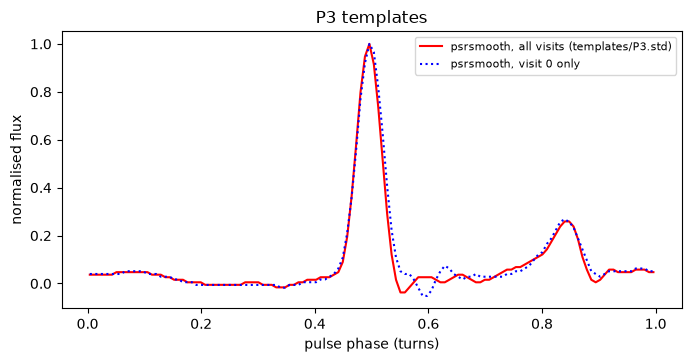

In [3]:
allft = " ".join(ft.values())
print(H.sh(f"psradd -T -F -P -o {OUT}/{PSR}_all {allft}"))
print(H.sh(f"psrsmooth -W -e std {OUT}/{PSR}_all"))
os.replace(OUT / f"{PSR}_all.std", OUT / f"{PSR}.std")

def prof(path):
    return H.data(H.load(path, fscrunch=True, tscrunch=True))[0, 0]

def align(ref, b):                    # rotate b onto ref (integer bins); both scaled to unit peak
    sft = np.argmax(np.fft.irfft(np.fft.rfft(ref) * np.conj(np.fft.rfft(b)), n=ref.size))
    return ref / ref.max(), np.roll(b, sft) / b.max()

tpl = prof(OUT / f"{PSR}.std")
tpl, t0 = align(tpl, prof(OUT / f"{PSR}_v0.std"))
ph = (np.arange(tpl.size) + 0.5) / tpl.size
fig, ax = plt.subplots(figsize=(8, 3.6))
AK = H.answer_key_dir(DS, PSR)
if AK is None:
    print("answer_key/ not present — skipping cal-template overlay (optional).")
else:
    _, cal = align(tpl, prof(AK / f"{PSR}_cal.std"))
    ax.plot(ph, cal, "k-", lw=2, label="noise-free calibration template (answer key)")
ax.plot(ph, tpl, "r-", label="psrsmooth, all visits (templates/P3.std)")
ax.plot(ph, t0, "b:", label="psrsmooth, visit 0 only")
ax.set(xlabel="pulse phase (turns)", ylabel="normalised flux", title=f"{PSR} templates")
ax.legend(fontsize=8); plt.show()


*Caption:* data-derived templates (red: all visits; blue dotted: visit 0) compared with the noise-free
template used to calibrate the simulation (black).

An alternative is an **analytic** template. **`paas`** (*PSRCHIVE analytic standard*) fits a sum of von
Mises components, the circular analogue of Gaussians. The options used:
- `-c "centre concentration height"` — the starting guess for each component;
- `-f` — fit them;
- `-L` — fit log(height), which keeps every height positive (without it, the fit can run away from
  these rough starting values);
- `-s` — the output standard;
- `-w` — the fitted model;
- `-j` — a text report;
- `-d /null` — no plot.

**What to look for:** the fitted centres near 0.49 and 0.84 turns.

In [4]:
print(H.sh(f'paas -c "0.49 400 1" -c "0.84 150 0.3" -f -L -s {OUT}/{PSR}_paas.std -w {OUT}/{PSR}_paas.m '
           f'-j {OUT}/{PSR}_paas.txt -d /null {OUT}/{PSR}_all'))
print((OUT / f"{PSR}_paas.m").read_text())

paas: reduced chisq=1.59045
paas: writing model to /Users/gudmundurstefansson/convening2026_work/templates/P3_paas.m
paas: writing standard to /Users/gudmundurstefansson/convening2026_work/templates/P3_paas.std

log height
    0.494883      71.7339  0.000409847 
    0.841475      71.7284  0.000149976 



## 2. Reduce each archive to NSUB profiles

A ToA needs a single profile, so each archive is summed over frequency and time. **`pam`** options:
- `--setnsub NSUB` — keep NSUB sub-integrations;
- `-F` — fscrunch;
- `-e tF` — write copies with extension `.tF`;
- `-u OUT/tF` — put them in that folder, leaving the originals untouched.

In [5]:
print(H.sh(f"pam --setnsub {NSUB} -F -e tF -u {OUT}/tF {' '.join(mine.path)}").splitlines()[-1])
tfs = sorted(glob.glob(f"{OUT}/tF/*.tF"))
print(len(tfs), "reduced archives")

/Users/gudmundurstefansson/convening2026_work/templates/tF/dsa13_chrsim-v00-p07-62513.8073_P3_v1.tF written to disk
6 reduced archives


## 3. Measure times of arrival

**`pat`** is PSRCHIVE's ToA generator. It cross-correlates each profile with the template. The shift, plus
the archive's time stamp, gives the ToA; the uncertainty comes from the S/N and the template shape.
Options:
- `-A FDM` — the Fourier-domain fit, with Markov-chain Monte Carlo error estimation;
- `-f tempo2` — tempo2 `.tim` format;
- `-s` — the template.

Each line is: archive, frequency (MHz), ToA (MJD, UTC), uncertainty (μs), site. The site is `gbt`: the
simulation uses the Green Bank Telescope's location as a stand-in for the DSA-2000.

In [6]:
tim = OUT / f"{PSR}.tim"
tim.write_text(H.sh(f"pat -A FDM -f tempo2 -s {OUT}/{PSR}.std {' '.join(tfs)}") + "\n")
print("\n".join(tim.read_text().splitlines()[:5]))
print("...", len(tim.read_text().splitlines()) - 1, "ToAs")

FORMAT 1
/Users/gudmundurstefansson/convening2026_work/templates/tF/dsa13_chrsim-v00-p03-62503.6219_P3_v1.tF 953.350000 62503.629159837916451  15.370  gbt 
/Users/gudmundurstefansson/convening2026_work/templates/tF/dsa13_chrsim-v00-p07-62513.8073_P3_v1.tF 953.350000 62513.814551000418382   9.439  gbt 
/Users/gudmundurstefansson/convening2026_work/templates/tF/dsa13_chrsim-v00-p08-62502.7215_P3_v1.tF 953.350000 62502.728808064671046  12.514  gbt 
/Users/gudmundurstefansson/convening2026_work/templates/tF/dsa13_chrsim-v00-p12-62512.8097_P3_v1.tF 953.350000 62512.816949456713396  16.787  gbt 
... 6 ToAs


## 4. Load into PINT and look at pre-fit residuals

**PINT** is a Python pulsar-timing package. `get_TOAs` reads the ToAs. It uses the DE440 Solar-System
ephemeris and includes planetary Shapiro delays; the helper also tags each ToA with its visit number,
read from the archive name. The model is the folding ephemeris `ephemerides/P3/fold.par`.

A **residual** is the measured ToA minus the model's prediction, wrapped to the nearest pulse.

**What to look for:**
- Visit 0 is flat: the ephemeris came from visit 0.
- Later visits drift away, and eventually jump around by up to ±P/2 ≈ ±3 ms. That is a **phase wrap**:
  the model no longer predicts which pulse is which.

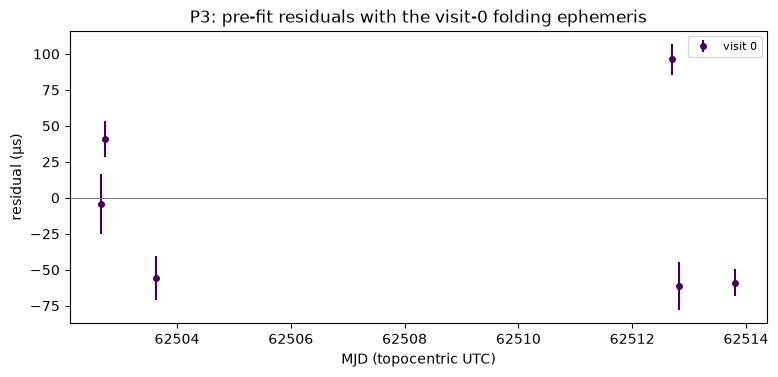

In [7]:
from pint.models import get_model
toas = H.load_toas(tim)
model0 = get_model(str(FOLD))
sess = H.TimingSession(toas, model0)
fig, ax = plt.subplots(figsize=(9, 3.8))
H.plot_residuals(ax, sess.residuals(), title=f"{PSR}: pre-fit residuals with the visit-0 folding ephemeris")
plt.show()


*Caption:* pre-fit residuals of all ToAs against the folding ephemeris, coloured by visit. Late
visits are wrapped because the visit-0 solution cannot predict them.

## 5. Phase-connect, visit by visit

We extend the solution one step at a time, refitting as we go. A ToA gets its pulse number the first
time it enters a fit: the nearest pulse predicted by the current model. After that it keeps it. A step works if the model
predicts the new visit to much better than half a turn.

The printed **χ²_red** (reduced chi-squared, χ² per degree of freedom) should be ≈ 1: the model then
fits at the noise level. A value ≫ 1 means an unmodelled effect or a wrong pulse-number assignment.

Parameters:
- `F0`, `F1` — spin frequency and its derivative;
- `RAJ`, `DECJ` — position;
- `PB`, `A1`, `TASC` — orbital period, projected semi-major axis, epoch of ascending node;
- `EPS1`, `EPS2` — the Laplace–Lagrange eccentricity parameters.

The walk-through below adds data step by step. **Each time χ²_red jumps, the model is missing
something.** The next step adds the parameter that fixes it:
1. visit 0 alone: F0 and the orbit (PB, A1, TASC); the orbit starts out assumed circular (EPS1 = EPS2 = 0);
2. add visit 1 with the same parameters → χ²_red jumps to ≈ 7. The orbit is not quite circular, and the
   eccentricity signature (≈ e·x ≈ 0.1 ms) is now visible;
3. free EPS1, EPS2 → χ²_red ≈ 0.2;
4. add visits 2–3 and F1 → χ²_red ≈ 4. The position (from imaging, good to ≈ 0.5″) now matters: a position
   error produces a yearly (annual) delay signal;
5. free RAJ, DECJ → χ²_red ≈ 0.8;
6. add visits 4–5, then all visits, with everything fitted.

(A `JUMP` is an arbitrary time offset for a group of ToAs. We do not need one here, but the interactive
panel below lets you add one per visit.)

In [8]:
orbit, ecc, pos = ["PB", "A1", "TASC"], ["EPS1", "EPS2"], ["RAJ", "DECJ"]
steps = [([0], ["F0"] + orbit),
         ([0, 1], ["F0"] + orbit),
         ([0, 1], ["F0"] + orbit + ecc),
         ([0, 1, 2, 3], ["F0", "F1"] + orbit + ecc),
         ([0, 1, 2, 3], ["F0", "F1"] + pos + orbit + ecc),
         ([0, 1, 2, 3, 4, 5], ["F0", "F1"] + pos + orbit + ecc),
         ([0, 1, 2, 3, 4, 5, 6], ["F0", "F1"] + pos + orbit + ecc)]
have = set(mine.visit)
steps = [(v, f) for v, f in steps if set(v) <= have]   # only visits on the bucket
for vis, free in steps:
    r = sess.fit(vis, free)
    print(f"visits {vis}: free {free}\n   {r['ntoa']} ToAs ({r['n_new']} new), chi2 = {r['chi2']:.1f} "
          f"for {r['dof']} dof, chi2_red = {r['chi2r']:.2f}")

visits [0]: free ['F0', 'PB', 'A1', 'TASC']
   6 ToAs (6 new), chi2 = 0.5 for 1 dof, chi2_red = 0.53


The final post-fit residuals and parameter table follow. **What to look for:** residuals scattered
around zero with no visit-dependent structure, and χ²_red ≈ 1. For 32 degrees of freedom, values between
about 0.6 and 1.5 are normal. The uncertainties are the formal 1σ errors from the fit.

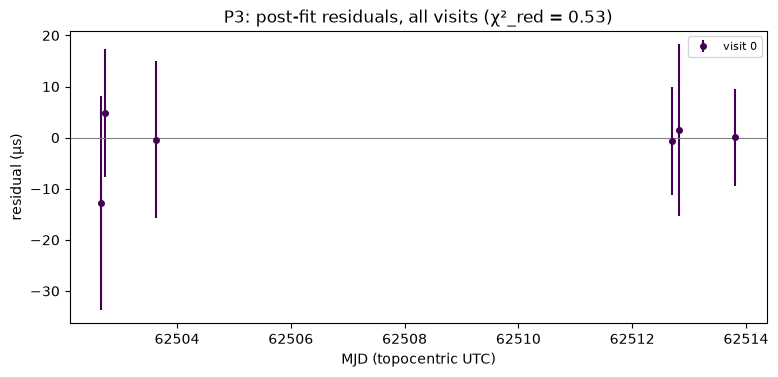

,parameter,value,uncertainty,fitted
0,F0,163.93442621911985563,2.983369e-08,True
1,F1,0.0,0.000000e+00,False
2,RAJ,19:09:00.26418258,0.000000e+00,False
3,DECJ,4:30:08.86884550,0.000000e+00,False
4,PB,4.3999791372464451197,1.335142e-05,True
5,A1,3.618682938849892,4.653094e-05,True
6,TASC,62506.499967870004155657,1.302844e-05,True
7,EPS1,0.0,0.000000e+00,False
8,EPS2,0.0,0.000000e+00,False


In [9]:
fig, ax = plt.subplots(figsize=(9, 3.8))
H.plot_residuals(ax, sess.last["fitter"].resids, title=f"{PSR}: post-fit residuals, all visits (χ²_red = {sess.last['chi2r']:.2f})")
plt.show()
sess.table()

*Caption:* post-fit residuals after connecting all 7 visits, coloured by visit.

### Interactive timing: do the connection yourself

The panel below repeats the walk-through, but you make the decisions. It works on its own copy of the
ToAs and model (`isess`), so the scripted results above are not affected.

**The controls**

| Control | What it does |
|---|---|
| **visits** list | The visits the next action uses. Ctrl-click (Cmd-click on a Mac) adds or removes one visit; Shift-click selects a range. |
| parameter boxes (F0 … EPS2) | The parameters the next **Fit** is allowed to change. Unticked ones stay fixed at their current values. |
| **JUMP vN** boxes | Give visit N a free constant time offset in the next fit (see below). |
| **Preview** | Plots **pre-fit** residuals of the selected visits against the *current* model, without fitting. Use it before adding a visit. |
| **Fit** | Fits the selected visits with the ticked parameters. Then plots post-fit residuals, χ²_red and the parameter table. |
| **Undo** | Goes back to the model (and pulse numbers) before the last Fit. You can press it repeatedly. |

**A recipe that works for P3.** The χ²_red values in brackets are what to expect.
1. **Visit 0 only.** It is pre-selected, with F0, PB, A1 and TASC ticked. Press **Fit**. Expect χ²_red well below 1; with only one degree of
   freedom the exact value is noisy.
2. **Add visit 1.** Ctrl-click visit 1, then press **Preview**. The visit-1 residuals should sit within a
   small fraction of the 6.1 ms period, with a smooth wiggle of about 0.1 ms: no phase wraps. Press
   **Fit** (≈ 7). That is too high: the orbit is not exactly circular. Tick **EPS1** and **EPS2**, then
   **Fit** again (≈ 0.2).
3. **Add visits 2 and 3.** **Preview**, then tick **F1** and **Fit** (≈ 4). Still too high: the
   position from imaging is only good to about 0.5″, which leaves a yearly signal. Tick **RAJ** and
   **DECJ**, then **Fit** (≈ 0.8).
4. **Add visits 4 and 5**, then **Preview**, then **Fit** (≈ 0.8).
5. **Add visit 6**, then **Fit** (≈ 1.1–1.4, about 32 degrees of freedom).

**How to read a Preview**
- **Safe to add:** all the new ToAs lie on a smooth curve, well inside ±P/2 ≈ ±3 ms. Every ToA can then
  be assigned the right pulse, so press **Fit**.
- **A phase wrap:** points scattered over the full ±3 ms, or jumping by about 6 ms (one period) between
  neighbours. The model cannot yet count pulses across the gap. Press nothing, and either free the
  missing parameter on the visits you already have, or add an intermediate visit first.

**Pulse numbers.** A ToA gets its pulse number the first time it enters a **Fit**: the pulse nearest
the current model's prediction. It keeps that number afterwards. So a wrong step cannot be repaired by
refitting; press **Undo** instead. To start completely afresh, re-run this cell.

**When to use a JUMP.** A JUMP lets a whole visit slide in time, which removes its absolute phase from
the fit. Use it when you are not sure a visit's pulse numbering is right: you can still fit its
internal shape, such as the orbit within the visit. Then remove the JUMP, which makes the visit
coherent with the rest, and check that χ²_red stays near 1. These simulated data need no JUMPs.

**Try breaking it:** add visits 4–6 before fitting the eccentricity and position, and **Preview**: the
wraps appear. If widgets are not available in your Jupyter, the cell prints a message instead; the
scripted cells above and the code cell below do the same thing.

Output()

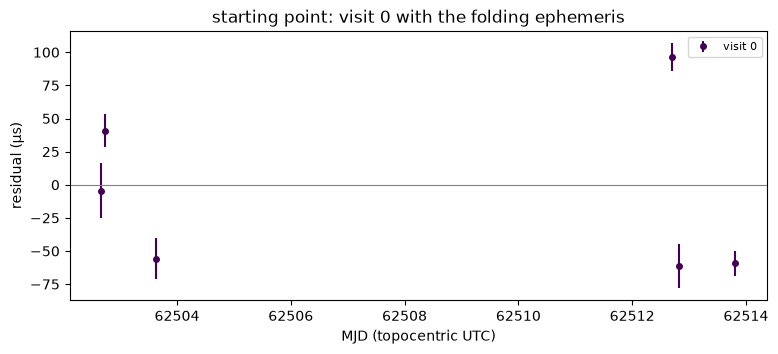

In [10]:
try:
    import ipywidgets as W
    from IPython.display import display, clear_output
    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False
    print("ipywidgets not installed: use sess.fit(visits, free, jumps) in a code cell instead.")

if HAVE_WIDGETS:
    isess = H.TimingSession(toas, model0)
    allvis = sorted(set(H.visits(toas)))
    w_vis = W.SelectMultiple(options=allvis, value=(0,), description="visits")
    w_par = [W.Checkbox(value=p in ("F0", "PB", "A1", "TASC"), description=p, indent=False)
             for p in ("F0", "F1", "RAJ", "DECJ", "PB", "A1", "TASC", "EPS1", "EPS2")]
    w_jmp = [W.Checkbox(value=False, description=f"JUMP v{v}", indent=False) for v in allvis[1:]]
    b_fit, b_undo = W.Button(description="Fit", button_style="primary"), W.Button(description="Undo")
    b_prev = W.Button(description="Preview", tooltip="pre-fit residuals of the selected visits, current model")
    out = W.Output()

    def show(msg=""):
        with out:
            clear_output()
            fig, ax = plt.subplots(figsize=(9, 3.5))
            sel = list(w_vis.value) or [0]
            H.plot_residuals(ax, isess.residuals(sel), title=f"visits {sel}")
            plt.show()
            print(msg)
            display(isess.table())

    def on_fit(_):
        free = [c.description for c in w_par if c.value]
        jumps = [int(c.description[6:]) for c in w_jmp if c.value]
        r = isess.fit(list(w_vis.value), free, jumps)
        show(f"fit: {r['ntoa']} ToAs, chi2_red = {r['chi2r']:.2f} ({r['dof']} dof)")

    def on_undo(_):
        isess.undo(); show("undone")

    def on_preview(_):
        show(f"PRE-FIT residuals of visits {list(w_vis.value)} with the current model (nothing fitted)")

    b_fit.on_click(on_fit); b_undo.on_click(on_undo); b_prev.on_click(on_preview)
    display(W.HBox([w_vis, W.VBox(w_par), W.VBox(w_jmp), W.VBox([b_prev, b_fit, b_undo])]), out)
    # starting point, shown as ordinary output; the panel above redraws only when you click
    # (drawing into the Output widget during cell execution stalls non-interactive runs)
    fig, ax = plt.subplots(figsize=(9, 3.5))
    H.plot_residuals(ax, isess.residuals([0]), title="starting point: visit 0 with the folding ephemeris")
    plt.show()

### The same, in code

Every button has a one-line equivalent, which is handy for recording what you did or scripting it:
- **Fit** is `s.fit(visits, free_params, jumps)`;
- **Undo** is `s.undo()`;
- **Preview** is `H.plot_residuals(ax, s.residuals(visits))`.

`s.residuals(visits)` evaluates *any* visits against the current model, including ones that have not
been fitted, so it gives the pre-fit residuals. The cell fits visit 0 in a fresh session, then shows
visits 0 and 1 against that new ephemeris. **What to look for:** visit 0 is flat, and visit 1 is
coherent with it, with a smooth wiggle of about 0.1 ms (the unfitted eccentricity).

visit 0 fit: chi2_red = 0.53


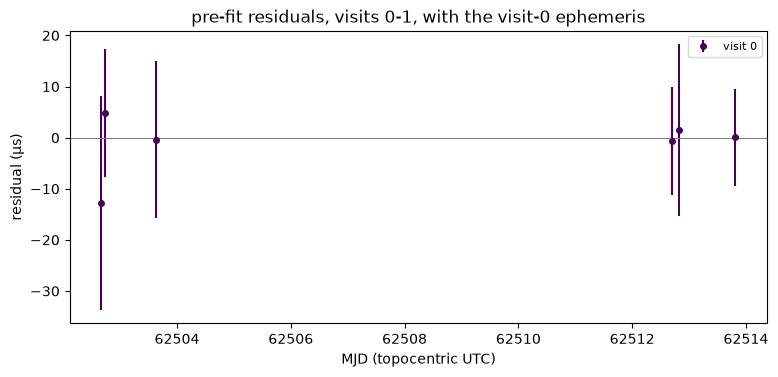

In [11]:
s = H.TimingSession(toas, model0)                 # fresh session from the folding ephemeris
r = s.fit([0], ["F0", "PB", "A1", "TASC"])          # step 1: visit 0 only
print(f"visit 0 fit: chi2_red = {r['chi2r']:.2f}")
fig, ax = plt.subplots(figsize=(9, 3.8))
H.plot_residuals(ax, s.residuals([0, 1]), title="pre-fit residuals, visits 0-1, with the visit-0 ephemeris")
plt.show()

*Caption:* pre-fit residuals of visits 0 and 1 against the ephemeris fitted to visit 0 alone. Visit 1
has not been used in the fit; its coherent, slightly curved residuals show it can safely be added.

## 6. Install the improved ephemeris into the archives

**`pam -E new.par`** replaces the archive's ephemeris and refolds the stored profiles with the new model
(PSRCHIVE uses tempo2 to build the new phase predictor). Other options: `-e ar2` writes copies with that
extension, and `-u OUT` writes them to the output folder.

We do this for a late-visit archive, where the visit-0 ephemeris had drifted. **What to look for:** in
the time–phase plot, the tilted or wandering pulse becomes a straight vertical line.

/Users/gudmundurstefansson/convening2026_work/templates/dsa13_chrsim-v00-p14-62502.6621_P3_v1.ar2 written to disk


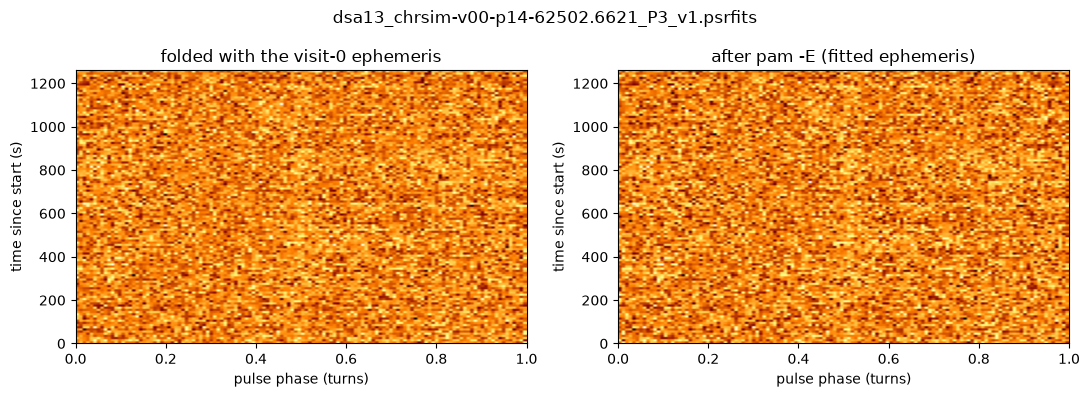

In [12]:
newpar = OUT / f"{PSR}_new.par"
newpar.write_text(sess.model.as_parfile(format="tempo2"))
late = mine[mine.visit == mine.visit.max()].iloc[0].path
print(H.sh(f"pam -E {newpar} -e ar2 -u {OUT} {late}"))
ar2 = OUT / (Path(late).stem + ".ar2")
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, p, t in ((axs[0], late, "folded with the visit-0 ephemeris"), (axs[1], ar2, "after pam -E (fitted ephemeris)")):
    d = H.data(H.load(p, fscrunch=True))[:, 0]
    ax.imshow(d, aspect="auto", origin="lower", extent=[0, 1, 0, 1260], cmap="afmhot")
    ax.set(xlabel="pulse phase (turns)", ylabel="time since start (s)", title=t)
plt.suptitle(Path(late).name); plt.tight_layout(); plt.show()

*Caption:* the same late-visit archive before (left) and after (right) installing the connected
ephemeris. The pulse no longer drifts within the pointing.

## 7. Compare with the answer key

**Pulls.** A pull is (fitted − true)/σ. If the fit and its uncertainties are right, pulls scatter like a
standard normal: most within ±2, and essentially none beyond ±3. The true model has its reference epoch
moved to the fit's `PEPOCH`, and `TASC` is compared modulo whole orbits.

**Uncertainties.** The survey simulation (`chrtiming`) gave each ToA a simple uncertainty
σ = δP/(S/N), where δ is the duty cycle. These archives were instead made to have `chrtiming`'s S/N.
Template matching on a real two-component profile does better than that simple formula. **What to look
for:** the ratio σ_pat/σ_chrtiming clusters well below 1 (≈ 0.3 for P3). The few large ratios come from
late-visit archives, where the visit-0 folding ephemeris smeared the pulse within the pointing.

In [13]:
AK = H.answer_key_dir(DS, PSR)
if AK is None:
    print('answer_key/ not present — skipping truth comparison (optional self-check).')
else:
    pl = H.pulls(sess.model, AK / "truth.par")
    print(pl.to_string(index=False, float_format=lambda x: f"{x:.6g}"))
    import pint.toa
    ct = pint.toa.get_TOAs(str(AK / "toas_chrtiming.tim"), ephem="DE440", planets=False)
    sig_ct = {(int(f["visit"]), int(f["ptg"])): e for f, e in zip(ct.table["flags"], ct.get_errors().to_value("us"))}
    rows = []
    for ln in tim.read_text().splitlines()[1:]:
        w = ln.split()
        if len(w) < 5:                      # skip blank / comment lines
            continue
        v, pt = H.visit_ptg(Path(w[0]).name)  # dsa13_chrsim-v03-p12-62608.5348_P3_v1.tF
        if (v, pt) in sig_ct:
            rows.append(float(w[3]) / sig_ct[(v, pt)])
    rows = np.array(rows)
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
    axs[0].bar(pl.parameter, pl.pull); axs[0].axhspan(-2, 2, color="0.9")
    axs[0].set(ylabel="(fit − truth) / σ", title="parameter pulls")
    axs[1].hist(rows, bins=15); axs[1].axvline(1, color="k")
    axs[1].set(xlabel="σ_pat / σ_chrtiming", ylabel="number of ToAs", title="ToA uncertainty ratio")
    plt.tight_layout(); plt.show()
    print(f"sigma_pat / sigma_chrtiming: median {np.median(rows):.3f}, range {rows.min():.2f}-{rows.max():.2f}")


answer_key/ not present — skipping truth comparison (optional self-check).


*Caption:* left, pulls of the fitted parameters against the true model (grey band ±2σ); right,
`pat`'s ToA uncertainties divided by the survey simulation's simple δP/(S/N), for matching pointings.

## What can go wrong

- **Missing CHR sample** → `FileNotFoundError: No MANIFEST.csv`. Download into `data/` and re-run
  from the top.
- **`pat` finds no template** (`Error loading standard`) → the template step did not run, or `OUT` changed.
  Re-run Section 1; `templates/P3.std` must exist.
- **A phase wrap in the interactive fit** (residuals jumping by about ±P/2, χ²_red ≫ 1) → you added a visit
  the current model cannot predict. Press **Undo**, add the missing parameter first (for P3 usually EPS1/EPS2
  or the position), or add the intermediate visits first.
- **PINT refuses a par-file keyword** (`UnknownParameter`) → remove or comment out that line. The
  `fold.par` files here are PINT-clean; hand-edited files from other packages may not be.


## Try next

- Start the connection with visits 0 and 2 instead of 0 and 1, and see whether the pulse numbering survives the longer gap.
- Leave `PB` out of the fit and watch the residuals trace the orbit.
- Remove the position from step 5 of the walk-through and see how χ²_red and the late-visit residuals react.
- Use the `paas` analytic template (`templates/P3_paas.std`) in `pat` and compare the ToA uncertainties.